In [1]:
%load_ext autoreload
%autoreload 2

import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import gsw
# import regionate
import cartopy.crs as ccrs
# import CM4Xutils #needed to run pip install nc-time-axis
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
import cartopy.feature as cfeature
import warnings
# from numpy import RankWarning
import cmocean as cm
warnings.filterwarnings('ignore')
import xesmf as xe
from meridional_streamfunction import * 

In [5]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

log_directory="/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs"

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='190GB',
    walltime='03:00:00',
    queue='scavenger',
    interface='ib0', 
log_directory = log_directory)
print(cluster.job_script())
cluster.scale(jobs=8)

client = Client(cluster)
client

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs/dask-worker-%J.err
#SBATCH -o /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs/dask-worker-%J.out
#SBATCH -p scavenger
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=177G
#SBATCH -t 03:00:00

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/bin/python -m distributed.cli.dask_worker tcp://172.16.3.73:37878 --name dummy-name --nthreads 36 --memory-limit 176.95GiB --nanny --death-timeout 60 --interface ib0



Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.16.3.73:37878,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [1]:
get_transports = lambda ds: ds[["umo", "vmo", "thkcello", "sigma2_i", "zos"]]
datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/budget_sigma2_v1.2.0/" + x

datafiles = glob.glob(datadir("CM4Xp125*"))[20:]
datafiles = sorted(datafiles)

ds_new = xr.open_mfdataset(
        datafiles,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        parallel=True,
        preprocess = get_transports, 
        engine="zarr")
# ds_new = ds_new.fillna(0.0)

NameError: name 'glob' is not defined

In [6]:
def get_psi_mean(ds):
    #this is the simplest approach. we can use this to get a sense for things
    grid = CM4Xutils.ds_to_grid(ds, Zprefix = "sigma2")
    
    #time mean velocity and thickenss
    vmo  = ds['vmo'].fillna(0.0).mean(dim='time').fillna(0.0)
    thk  = ds['thkcello'].fillna(0.0).mean(dim='time')
    
    zrho_masked = thk.cumsum(dim='sigma2_l').where(thk.sum(dim='sigma2_l') > 0).mean(dim='xh', skipna=True) #mask land cells

    vmo_xsum = vmo.fillna(0.0).sum(dim='xh').fillna(0.0)
    psi      = (vmo_xsum.cumsum(dim='sigma2_l') - vmo_xsum.sum(dim='sigma2_l'))/1e9 
    psi.name = 'meridional-sigma2 overturning'
    
    # defined by zonal mean of the time mean depth of rho
    psi.coords['depth'] = grid.interp(zrho_masked, 'Y', boundary='extend')
    psi.coords['depth_masked'] = grid.interp(zrho_masked, 'Y', boundary='extend')
    
    psi.coords['lat'] = ds["geolat_v"].mean(dim='xh')
    return psi.compute()

Text(0.5, 1.0, 'Meridional Isopycnal Streamfunction\n(forced)')

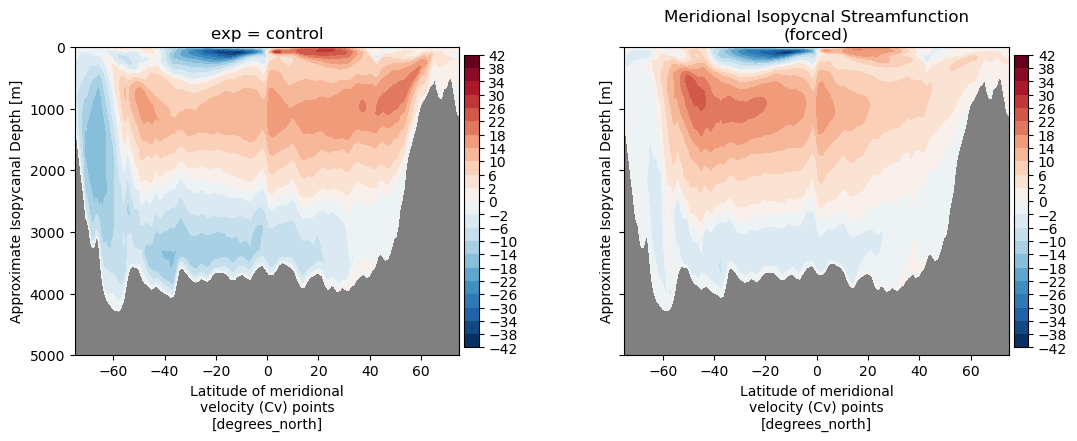

In [7]:
#define streamfunction levels
def plot_psi(fig, ax, psi): 
    levels = [-42, -38, -34, -30, -26, -22, -18, -14, -10, -6, -2, 0,   2,   6,  10,  14,  18,  22,  26,  30,  34,  38,  42]
    p1 = psi.plot.contourf(
        ax=ax, x="lat", y="depth", levels=levels,
        add_colorbar=False, cmap='RdBu_r'
    )
    c1 = fig.colorbar(p1, ax=ax, pad=0.01, spacing='uniform',
                      extend='both', shrink=0.95, orientation='vertical')
    c1.set_ticks(levels)
    c1.ax.tick_params(labelsize=10)
    ax.set_facecolor('gray')
    ax.set_xlim(-75, 75)
    ax.set_ylim(0, 5000)
    ax.invert_yaxis()
    ax.set_ylabel("Approximate Isopycanal Depth [m]")

psi_new = get_psi_mean(ds_new)

# create one figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

# first subplot: control
exp = "control"
ax = axes[0]
plot_psi(fig, ax, psi_new.fillna(0.0).sel(exp=exp))

# first subplot: forced
exp = "forced"
ax = axes[1]
plot_psi(fig, ax, psi_new.fillna(0.0).sel(exp=exp))
ax.set_title(f"Meridional Isopycnal Streamfunction\n(forced)")


Setting up XGCM Grid...


Text(0.5, 1.0, 'Meridional Isopycnal Streamfunction\n(forced)')

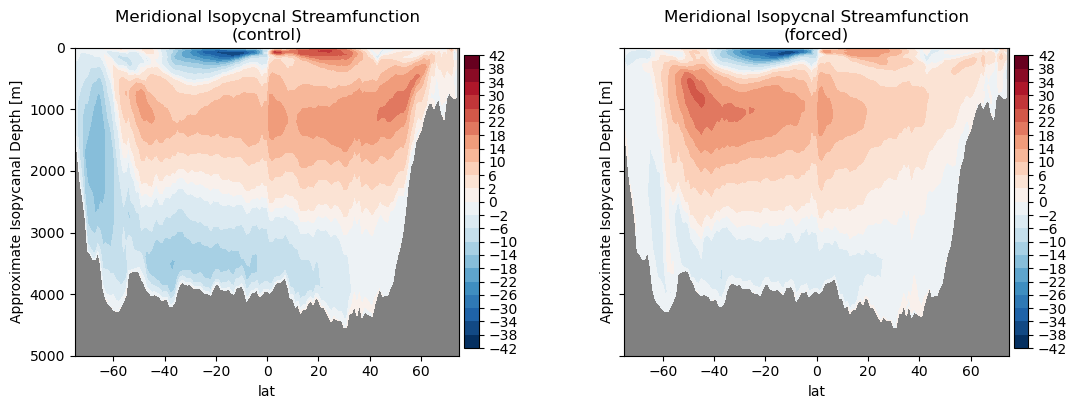

In [7]:
lats = np.arange(-75, 75, 1)
psi = get_psi_mean_convergence(ds_new, lats).compute()

# create one figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

# first subplot: control
ax = axes[0]
exp = "control"
psi_new = psi["psi"].fillna(0.0).sel(exp=exp)
psi_new.coords["depth"] = psi["depth"].sel(exp=exp)
plot_psi(fig, ax, psi_new.fillna(0.0))
ax.set_title(f"Meridional Isopycnal Streamfunction\n(control)")

# first subplot: forced
exp = "forced"
ax = axes[1]
psi_new = psi["psi"].fillna(0.0).sel(exp=exp)
psi_new.coords["depth"] = psi["depth"].sel(exp=exp)
plot_psi(fig, ax, psi_new.fillna(0.0))
ax.set_title(f"Meridional Isopycnal Streamfunction\n(forced)")

Setting up XGCM Grid...


Text(0.5, 1.0, 'Meridional Isopycnal Streamfunction\n(forced)')

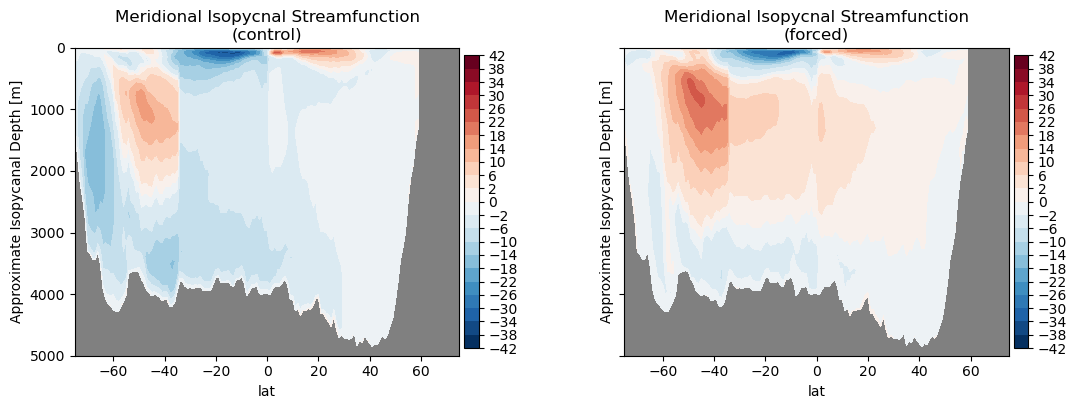

In [8]:
import cmip_basins.cmip6 as cmip6_basins
from cmip_basins.basins import generate_basin_codes

codes = generate_basin_codes(ds_new, lon="geolon", lat="geolat", persian=True, style="cmip6")

so_ind_pac_mask = codes.isin([1, 3, 5, 10, 11])
so_ind_pac_mask = so_ind_pac_mask.where(so_ind_pac_mask > 0.0)

grid = CM4Xutils.ds_to_grid(ds_new, Zprefix="sigma2")

c_mask = so_ind_pac_mask.where(ds_new.wet > 0.0)
v_mask = grid.interp(so_ind_pac_mask, axis="Y", boundary = "extend").where(ds_new.wet_v > 0.0)

ds_ind_pac = 1 * ds_new 
ds_ind_pac["thkcello"] = ds_ind_pac["thkcello"].where(c_mask > 0.0)
ds_ind_pac["zos"] = ds_ind_pac["zos"].where(c_mask > 0.0)
ds_ind_pac["wet"] = ds_ind_pac["wet"].where(c_mask > 0.0)
ds_ind_pac["vmo"] = ds_ind_pac["vmo"].where(v_mask > 0.0)
ds_ind_pac["wet_v"] = ds_ind_pac["wet_v"].where(v_mask > 0.0)

lats = np.arange(-75, 60, 1)
psi = get_psi_mean_convergence(ds_ind_pac, lats).compute()

# create one figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

# first subplot: control
ax = axes[0]
exp = "control"
psi_new = psi["psi"].fillna(0.0).sel(exp=exp)
psi_new.coords["depth"] = psi["depth"].sel(exp=exp)
plot_psi(fig, ax, psi_new.fillna(0.0))
ax.set_title(f"Meridional Isopycnal Streamfunction\n(control)")

# first subplot: forced
exp = "forced"
ax = axes[1]
psi_new = psi["psi"].fillna(0.0).sel(exp=exp)
psi_new.coords["depth"] = psi["depth"].sel(exp=exp)
plot_psi(fig, ax, psi_new.fillna(0.0))
ax.set_title(f"Meridional Isopycnal Streamfunction\n(forced)")

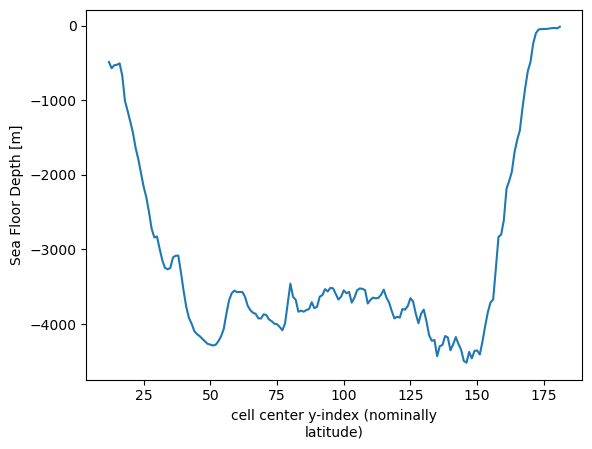

In [9]:
(-ds_new["deptho"]).where(so_ind_pac_mask > 0.0).mean(["xh"], skipna = True).plot()